# Understanding Word Embeddings: From Intuition to Implementation

Welcome to this hands-on guide to word embeddings. The fundamental challenge in natural language processing (NLP) is that machines don't understand words; they understand numbers. This notebook explores how we can represent words as meaningful numerical vectors, a concept that powers nearly all modern NLP.

We will cover four key areas:

1.  **Part 1: The Core Idea & Visualization**: We'll start with *why* we need embeddings and build intuition by visualizing word relationships in 2D space.
2.  **Part 2: Learning Embeddings from Scratch**: You'll build a small neural network (a Skip-gram model) to see how these vectors are actually learned from a text corpus.
3.  **Part 3: Using Pre-Trained Embeddings**: You'll learn to leverage powerful, pre-trained embeddings (GloVe) to quickly build a high-performing text classification model.
4.  **Part 4: Exploring Word Analogies**: You'll perform vector math on words to solve analogies like `king - man + woman = queen`, proving that the embeddings have captured true semantic relationships.

## Learning Objectives
- Understand the limitations of one-hot encoding for representing words.
- Grasp the core concept of a **dense word embedding**.
- Visualize semantic relationships between words using dimensionality reduction (PCA).
- Implement a simple **Skip-gram model** to learn embeddings from a small corpus.
- Load and use **pre-trained GloVe embeddings** in a Keras model.
- Apply embeddings to solve a practical text classification problem.
- Use **cosine similarity** and vector arithmetic to find word similarities and solve analogies.

---

## Part 1: The Core Idea & Visualization

How can we represent words numerically? The simplest way is **one-hot encoding**, where each word is a huge vector of all zeros and a single one. This approach has two major flaws:

1.  **Sparsity**: With a vocabulary of 50,000 words, each word's vector would have 50,000 dimensions, making it incredibly inefficient.
2.  **No Meaning**: The one-hot vectors for "king" and "queen" are no more related to each other than the vectors for "king" and "apple." They capture zero semantic relationship.

**Word embeddings** solve this by representing words as short, dense vectors (e.g., 100 dimensions instead of 50,000). Words with similar meanings will have similar vectors. Let's visualize this.

### 1.1 Setup and Visualization

Download complete. ✅
Found 400000 word vectors.


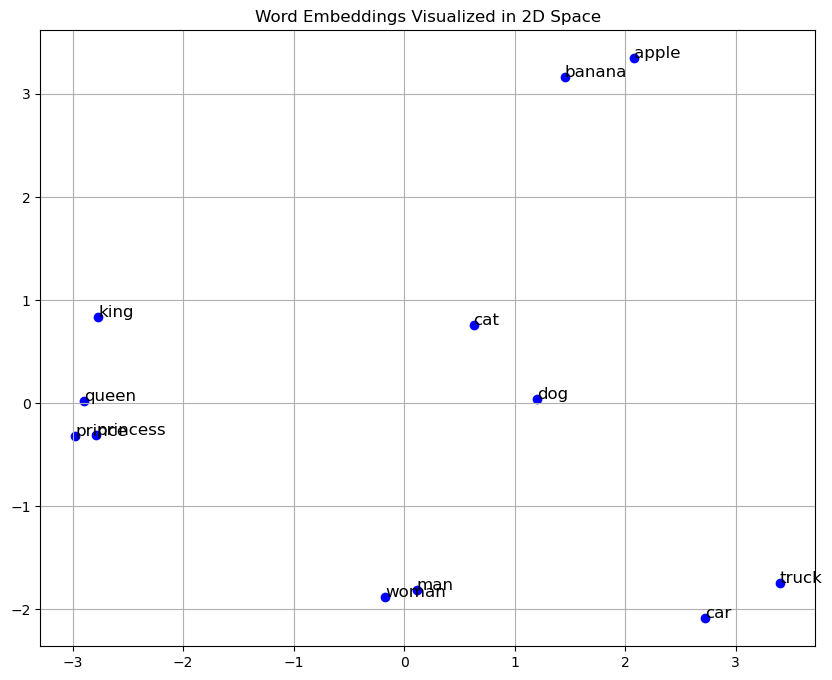

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import requests
import zipfile
import os

# Set random seeds for consistent results
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download a small set of GloVe pre-trained embeddings
if not os.path.exists('glove.6B.50d.txt'):
    print("Downloading GloVe embeddings...")
    r = requests.get('http://nlp.stanford.edu/data/glove.6B.zip')
    with open('glove.6B.zip', 'wb') as f:
        f.write(r.content)
    with zipfile.ZipFile('glove.6B.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Download complete. ✅")

# Load embeddings into a dictionary
embeddings_index = {}
with open("glove.6B.50d.txt") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs
print(f"Found {len(embeddings_index)} word vectors.")

# Function to plot embeddings
def plot_embeddings(words):
    vectors = np.array([embeddings_index[word] for word in words])
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='blue')
    for i, word in enumerate(words):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=12)
    plt.title("Word Embeddings Visualized in 2D Space")
    plt.grid(True)
    plt.show()

# Words to visualize
words_to_plot = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'dog', 'cat', 'banana', 'apple', 'car', 'truck']
plot_embeddings(words_to_plot)

Notice how related concepts cluster together: 'king' and 'queen' are near each other, as are 'apple' and 'banana'. The vector relationship between 'man' and 'woman' is visibly similar to the one between 'king' and 'queen'. This is the magic of embeddings!

---

## Part 2: Learning Embeddings from Scratch

How does a model learn these relationships? The core idea is the **Distributional Hypothesis**: "a word is characterized by the company it keeps." We can train a simple neural network to predict a word's context, and in the process, the network will learn excellent word embeddings.

We will use the **Skip-gram** architecture. The task is simple: given a target word (e.g., "fox"), we'll train the model to predict a context word that appears nearby (e.g., "quick" or "brown").

### 2.1 Setup and Corpus Preparation

In [ ]:
from keras.preprocessing.text import Tokenizer

# A very small corpus
corpus = [
    'the quick brown fox jumps over the lazy dog',
    'the king and queen ruled the kingdom',
    'a man and a woman walked down the street',
    'the prince is the son of the king'
]

# Tokenize the corpus
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
sequences = tokenizer.texts_to_sequences(corpus)

vocab_size = len(tokenizer.word_index) + 1
word_index = tokenizer.word_index
print(f"Vocabulary Size: {vocab_size}")

# Generate skip-gram pairs
skip_grams = [keras.preprocessing.sequence.skipgrams(seq, vocabulary_size=vocab_size, window_size=5) for seq in sequences]

# Unpack the pairs and labels
pairs = []
labels = []
for el in skip_grams:
    pairs.extend(el[0])
    labels.extend(el[1])

target_word, context_word = zip(*pairs)
target_word = np.array(target_word)
context_word = np.array(context_word)
labels = np.array(labels)

print(f"Generated {len(labels)} skip-gram pairs. ✅")

### 2.2 Building and Training the Skip-gram Model

In [ ]:
# -- Hyperparameters for Skip-gram --
EMBED_DIM = 50

# Define the model inputs
input_target = layers.Input((1,))
input_context = layers.Input((1,))

# The Embedding layer is what we're really after. Its weights are the word vectors.
embedding = layers.Embedding(vocab_size, EMBED_DIM, name="embedding_layer")

# Look up the embeddings for the target and context words
target_vector = embedding(input_target)
target_vector = layers.Reshape((EMBED_DIM, 1))(target_vector)

context_vector = embedding(input_context)
context_vector = layers.Reshape((EMBED_DIM, 1))(context_vector)

# Use dot product to measure similarity and a dense layer to get a prediction
dot_product = layers.Dot(axes=1)([target_vector, context_vector])
dot_product = layers.Reshape((1,))(dot_product)
output = layers.Dense(1, activation='sigmoid')(dot_product)

skipgram_model = keras.Model(inputs=[input_target, input_context], outputs=output)
skipgram_model.compile(loss='binary_crossentropy', optimizer='adam')

print("Training Skip-gram model...")
skipgram_model.fit([target_word, context_word], labels, epochs=50, verbose=1)

# Extract the learned weights from the embedding layer
learned_embeddings = skipgram_model.get_layer("embedding_layer").get_weights()[0]

# Let's look at the vector for the word 'king'
king_vector = learned_embeddings[word_index['king']]
print(f"\nLearned vector for 'king' (first 5 dims): {king_vector[:5]}")

---

## Part 3: Using Pre-Trained Embeddings for Classification

Training embeddings from scratch requires a massive amount of data and computation. In practice, it's almost always better to start with embeddings that have been pre-trained on a huge corpus like Wikipedia or Google News.

Here, we'll use the GloVe embeddings we downloaded earlier to solve a real-world task: sentiment analysis on movie reviews from the IMDb dataset.

### 3.1 Setup and Data Preparation

In [ ]:
# -- Hyperparameters for Classification --
VOCAB_SIZE_CLS = 10000
MAX_LEN_CLS = 250
EMBED_DIM_CLS = 50 # Must match the GloVe dimension we loaded

# Load IMDb data
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE_CLS)

# Pad sequences to a fixed length
x_train = keras.utils.pad_sequences(x_train, maxlen=MAX_LEN_CLS)
x_test = keras.utils.pad_sequences(x_test, maxlen=MAX_LEN_CLS)

# Get the word-to-index mapping from the dataset
word_index_cls = keras.datasets.imdb.get_word_index()

# Create the embedding matrix
num_tokens = min(VOCAB_SIZE_CLS, len(word_index_cls) + 1)
embedding_matrix = np.zeros((num_tokens, EMBED_DIM_CLS))

for word, i in word_index_cls.items():
    if i >= VOCAB_SIZE_CLS:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

print("Embedding matrix created. ✅")

### 3.2 Building and Training the Classifier

In [ ]:
# Create the Embedding layer, loading our pre-trained weights
embedding_layer = layers.Embedding(
    num_tokens,
    EMBED_DIM_CLS,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False, # We freeze the embeddings
)

# Build the classification model
inputs = layers.Input(shape=(MAX_LEN_CLS,))
x = embedding_layer(inputs)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

cls_model = keras.Model(inputs=inputs, outputs=outputs)
cls_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training classification model...")
history_cls = cls_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
)

loss, acc = cls_model.evaluate(x_test, y_test)
print(f"\nClassification Test Accuracy: {acc*100:.2f}%")

---

## Part 4: Exploring Word Analogies

Now for the most famous and intuitive demonstration of word embeddings: vector arithmetic. Because the vectors capture semantic relationships, we can perform mathematical operations on them to solve analogies.

First, we'll define a function to find the most similar words to a given word using **cosine similarity**, which measures the angle between two vectors. Then, we'll use that logic to solve analogies.

### 4.1 Word Arithmetic: Solving Analogies

In [ ]:
# Pre-calculate normalized embeddings for efficiency
all_words, all_vectors = zip(*embeddings_index.items())
all_vectors = np.array(all_vectors)
all_vectors_norm = all_vectors / np.linalg.norm(all_vectors, axis=1, keepdims=True)
word_to_vec_map = {word: vec for word, vec in embeddings_index.items()}

def find_most_similar(vec):
    # Calculate cosine similarity between the input vector and all word vectors
    vec_norm = vec / np.linalg.norm(vec)
    sim = np.dot(all_vectors_norm, vec_norm.T)
    # Find the indices of the top 5 most similar words
    top_indices = np.argsort(sim)[-6:-1][::-1] # Exclude the word itself
    return [all_words[i] for i in top_indices]

def solve_analogy(word1, word2, word3):
    # vec(word1) - vec(word2) + vec(word3)
    try:
        vec1 = word_to_vec_map[word1]
        vec2 = word_to_vec_map[word2]
        vec3 = word_to_vec_map[word3]
    except KeyError as e:
        return f"Error: '{e.args[0]}' not in vocabulary."
        
    result_vec = vec1 - vec2 + vec3
    closest_word = find_most_similar(result_vec)[0]
    return closest_word

# --- Test Analogies ---
print("Solving analogy: 'king' - 'man' + 'woman' ≈ ...")
result = solve_analogy('king', 'man', 'woman')
print(f"Result: {result.upper()}\n") # Expected: queen

print("Solving analogy: 'paris' - 'france' + 'germany' ≈ ...")
result = solve_analogy('paris', 'france', 'germany')
print(f"Result: {result.upper()}\n") # Expected: berlin

print("Solving analogy: 'walking' - 'walk' + 'swim' ≈ ...")
result = solve_analogy('walking', 'walk', 'swim')
print(f"Result: {result.upper()}\n") # Expected: swimming

print("Finding words similar to 'music':")
similar_words = find_most_similar(word_to_vec_map['music'])
print(similar_words)

---

## Conclusion

In this notebook, you have explored the concept of word embeddings from the ground up, gaining both theoretical intuition and practical skills.

1.  You **visualized** how embeddings place words with similar meanings close together in vector space, solving the core weakness of one-hot encoding.
2.  You built a **Skip-gram model** from scratch, revealing the underlying mechanism used to learn these meaningful representations from raw text.
3.  You leveraged powerful **pre-trained GloVe embeddings** to build a high-performing sentiment classifier, demonstrating the power of transfer learning in NLP.
4.  You performed **word arithmetic** to solve analogies, providing the most compelling evidence that these vectors truly capture the rich semantic relationships between words.

Understanding word embeddings is the first major step toward mastering modern NLP. These dense vector representations are the foundation upon which more complex architectures, like the Transformer, are built.